In [1]:
################################################################
## Import libraries
import numpy as np
np.set_printoptions(suppress=True)
import matplotlib.pyplot as plt
import sys
from pathlib import Path
################################################################
src_path = Path().resolve().parent / "src"
sys.path.insert(0, str(src_path))
#################################################################################
from recday_info import load_units, get_mouse_info_single, get_cell_inds_one_mouse, get_sessions, multi_ctype_IDs, display_unit_df
from plotting import plot_event_raster, plot_psth, plot_individual_event_rasters
from spike_helper import generate_ifr_one_day
from my_mpl_defaults import *
#################################################################################

In [2]:
#### Basic parameters ##########################################################
nms = (200,200)
binwidth = 1
ctype_list = ['pdg','p3','p1']
###############################################################################################
event_type_list = ['ds','swr']
ext_list = ['.ds_pulse','.swr_pulse']
###############################################################################################
sleepbox = True
sleeponly = True
###############################################################################################
fscale = (12,14)
###############################################################################################

In [3]:
###################################################################################################################
path_to_data = 'data/msm16-181018'
###################################################################################################################
BASE_DIR = Path.cwd().parent
###################################################################################################################

In [4]:
##### get recording day information ###############################################################
ipath, bsnm, baseblock, par, desen, units = get_mouse_info_single(BASE_DIR, path_to_data)
unit_IDs = get_cell_inds_one_mouse(units,ctype_list=ctype_list,exact=True)
sessions = get_sessions(desen,sleepbox=sleepbox,sleeponly=sleeponly)
####################################################################################################

#### Generate an instantaneous firing rate matrix (IFR) for one neuron from one recording day
#### ...and visualize the data as a z-scored peri-event time histogram and as a raster plot
As shown in McHugh et al. 2024, Neuron, doi:Figure 1c-e

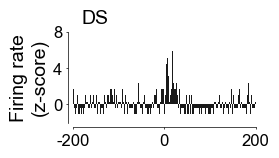

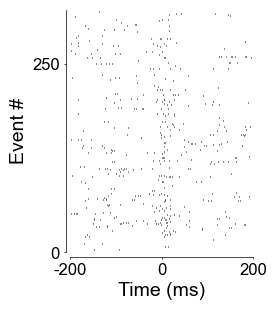

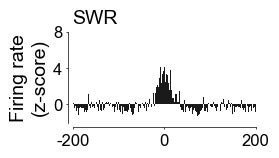

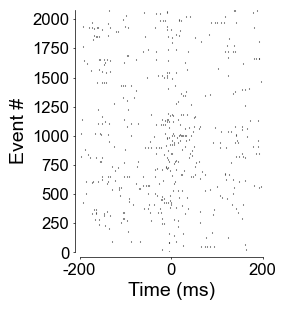

In [5]:
#### Generate IFR for one neuron ##################################################################
cluID_dict = {'DG': 8, 'CA3': 20, 'CA1': 39} # one example neuron for each hippocampal region
region = 'DG'
cluID = [cluID_dict[region]] # cluID identifies individual neurons
# cluID can be any integer value between [2 and len(units)+1], e.g. cluID = [2], but must be passed as a list

### generate IFRs for each event_type from event_type_list for one neuron ####################################
event_dict = generate_ifr_one_day(baseblock,desen,sessions,cluID,unit_IDs,nms,binwidth,ext_list)
##############################################################################################################
for indx,(event,ext) in enumerate(zip(event_type_list,ext_list)):
    actmat = np.squeeze(event_dict[event])
    if actmat.ndim > 2:
        raise ValueError("Error: array has more than 2 dimensions, pass one value to cluID_list for plotting")
    ###########################################################################################################
    fig,ax = plot_psth(actmat,
                       nms=nms,
                       binwidth=binwidth,
                       zrange=(0,200),
                       fwd=3,
                       fht=1.5,
                       col='k',
                       x_maj_loc=200,
                       y_maj_loc=4,
                       yt_fmt='.0f',
                       set_lims=True,
                       ylim=(-2,8),
                       xlab='',
                       ylab='Firing rate\n(z-score)',
                       size_scale=2,
                       fscale=fscale,
                       pad=3)
    ##################################################################
    ax.set_title(event.upper(),y=+1.0,x=+.12,fontsize=fscale[1])
    plt.show()
    ##################################################################
    fig,ax = plot_event_raster(actmat,
                               nms=nms,
                               binwidth=binwidth,
                               fwd=3,
                               fht=4,
                               col='k',
                               x_maj_loc=200,
                               y_maj_loc=250,
                               yt_fmt='.0f',
                               despine_x=False,
                               despine_y=False,
                               lw=lw,
                               size_scale=2,
                               fscale=fscale,
                               ylab='Event #',
                               pad=3)
    plt.show()
    ##################################################################

#### If we want to, we generate an instantaneous firing rate matrix (IFR) for all prinicpal neurons 
#### from one recording day: time (ms) x neurons x event_index array for each event_type
This will be 400 x 46 x 322 numpy array for dentate spike events <br>
... and a    400 x 46 x 2080 numpy array for sharp-wave ripple events <br>
These are stored in a dictionary (ifr_dict)

In [6]:
##########################################################################################################
cluID_list = multi_ctype_IDs(ctype_list,unit_IDs) # this will get the unit_IDs of the principal cells in DG, CA3 and CA1
ifr_dict = generate_ifr_one_day(baseblock,desen,sessions,cluID_list,unit_IDs,nms,binwidth,ext_list)
##########################################################################################################

#### We can now visualize the spike trains of all neurons during individual events
Below are the first 5 events for dentate spikes and sharp-wave ripples
<br> Similar visualizations can be seen in Figure 3A and Figure 4A in McHugh et al. 2024, Neuron, doi:

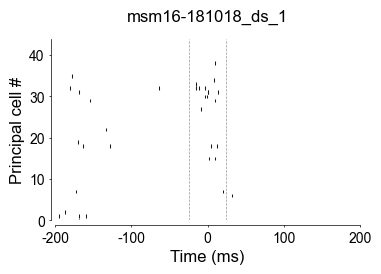

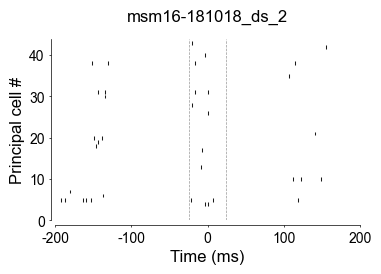

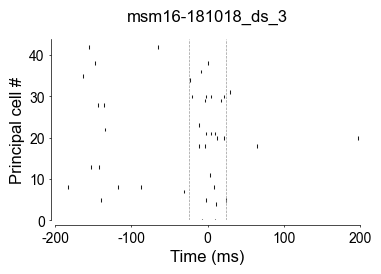

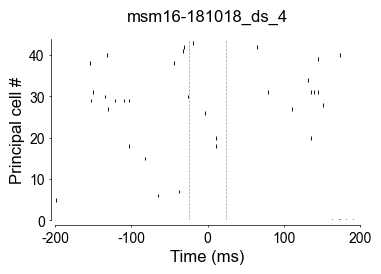

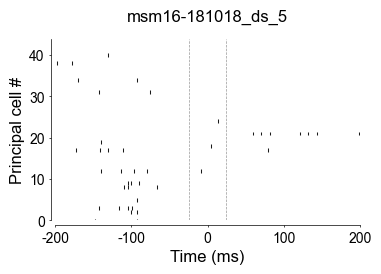

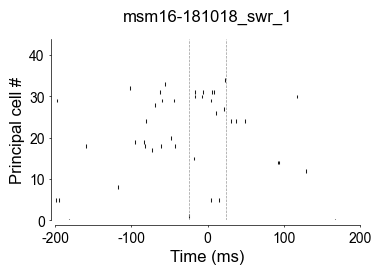

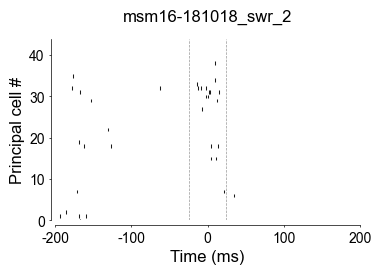

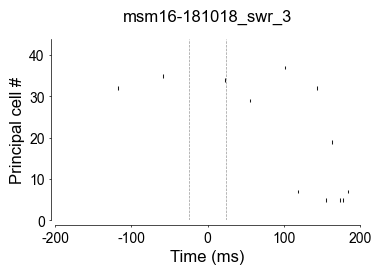

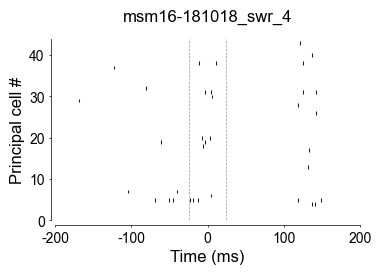

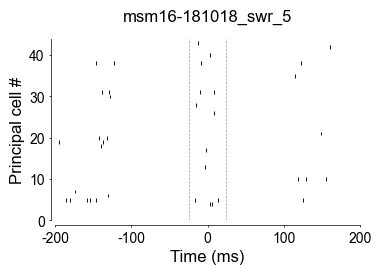

In [7]:
#################################################################################################
ev_indx_list = [0,1,2,3,4] # here we select the event indices to vizualise
#################################################################################################
plot_individual_event_rasters(ifr_dict,
                              ev_indx_list,
                              bsnm,
                              nms,
                              binwidth)

In [8]:
display_unit_df(units,ctype_list)

,trode,trode_unit,des
8,2,0,pdg
9,2,1,pdg
13,2,5,pdg
14,3,0,pdg
15,3,1,pdg
17,3,3,pdg
46,9,0,pdg
50,10,0,pdg
51,10,1,pdg
52,10,2,pdg


,trode,trode_unit,des
2,1,0,p3
3,1,1,p3
4,1,2,p3
5,1,3,p3
6,1,4,p3
18,4,0,p3
19,4,1,p3
20,4,2,p3
25,5,2,p3
26,5,3,p3


,trode,trode_unit,des
31,6,0,p1
32,6,1,p1
33,6,2,p1
34,6,3,p1
39,7,2,p1
40,7,3,p1
42,7,5,p1
58,11,0,p1
59,11,1,p1
60,11,2,p1


In [11]:
ifr_dict['ds'].shape

(400, 44, 322)

In [14]:
mpath = str(BASE_DIR)
output_path = 'data/one_day_ifr'
fname = 'example_one_day_ifr'
odata = ifr_dict

print(mpath+output_path)

/home/smchugh/Projects/neuron_2024_reprodata/one_day_ifr


In [16]:
import data_io as dio
fullpath =  dio.save_npy_data(mpath,output_path,fname,odata)
print(fullpath)

/home/smchugh/Projects/neuron_2024_repro/data/one_day_ifr/example_one_day_ifr
